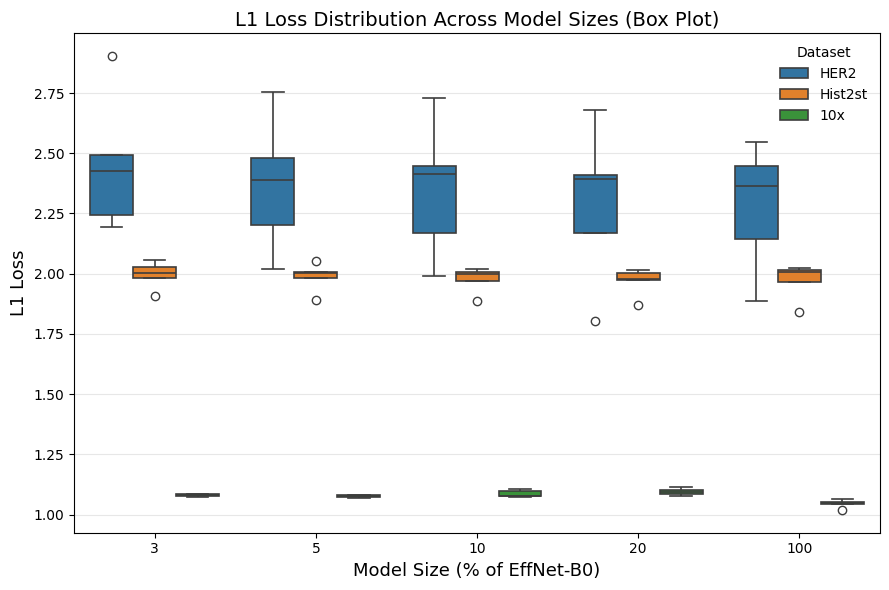

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("all_models_per_fold_metrics.csv")

# Clean columns
df["model"] = df["model"].str.strip()
df["dataset"] = df["dataset"].str.strip()

# Extract model size
df["size"] = df["model"].str.extract(r"EffNet-(\d+)").astype(int)

# Keep only desired model sizes
order_sizes = [3, 5, 10, 20, 100]
df = df[df["size"].isin(order_sizes)]

# Ensure correct order on x-axis
df["size"] = pd.Categorical(df["size"], categories=order_sizes, ordered=True)

# Plot
plt.figure(figsize=(9, 6))
sns.boxplot(
    data=df,
    x="size",
    y="l1_mean",
    hue="dataset",
    showfliers=True,     # show outliers
    linewidth=1.2
)

plt.xlabel("Model Size (% of EffNet-B0)", fontsize=13)
plt.ylabel("L1 Loss", fontsize=13)
plt.title("L1 Loss Distribution Across Model Sizes (Box Plot)", fontsize=14)

plt.grid(alpha=0.3, axis="y")
plt.legend(title="Dataset", frameon=False)
plt.tight_layout()
plt.savefig("l1_boxplot_by_dataset.png", dpi=300)
plt.show()


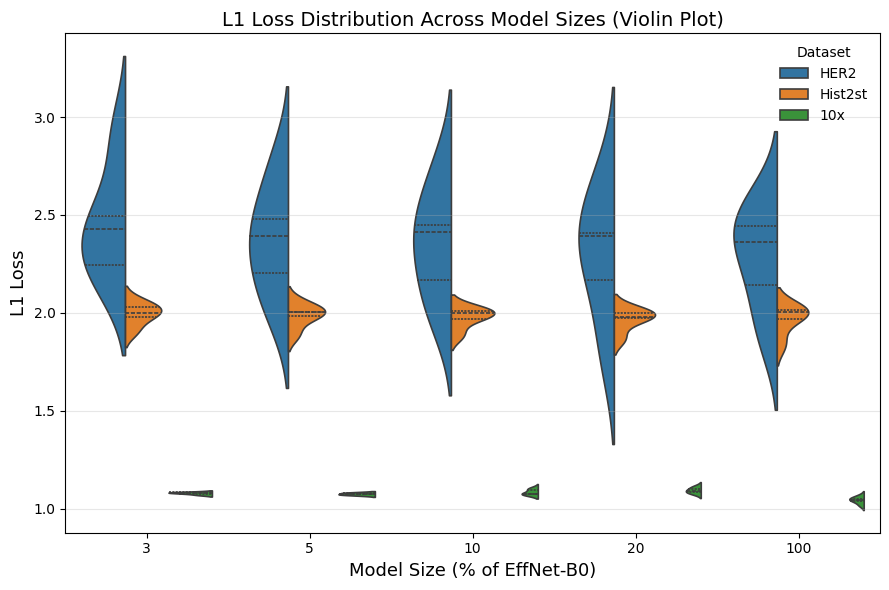

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("all_models_per_fold_metrics.csv")

# Clean columns
df["model"] = df["model"].str.strip()
df["dataset"] = df["dataset"].str.strip()

# Extract model size
df["size"] = df["model"].str.extract(r"EffNet-(\d+)").astype(int)

# Keep only desired model sizes
order_sizes = [3, 5, 10, 20, 100]
df = df[df["size"].isin(order_sizes)]

# Sort sizes for proper x-axis order
df["size"] = pd.Categorical(df["size"], categories=order_sizes, ordered=True)

# Plot
plt.figure(figsize=(9, 6))
sns.violinplot(
    data=df,
    x="size",
    y="l1_mean",
    hue="dataset",
    split=True,        # nice symmetric violins per dataset (if only 2 datasets; else set False)
    inner="quartile",
    linewidth=1.2
)

plt.xlabel("Model Size (% of EffNet-B0)", fontsize=13)
plt.ylabel("L1 Loss", fontsize=13)
plt.title("L1 Loss Distribution Across Model Sizes (Violin Plot)", fontsize=14)

plt.grid(alpha=0.3, axis="y")
plt.legend(title="Dataset", frameon=False)
plt.tight_layout()
plt.savefig("l1_violin_by_dataset.png", dpi=300)
plt.show()
